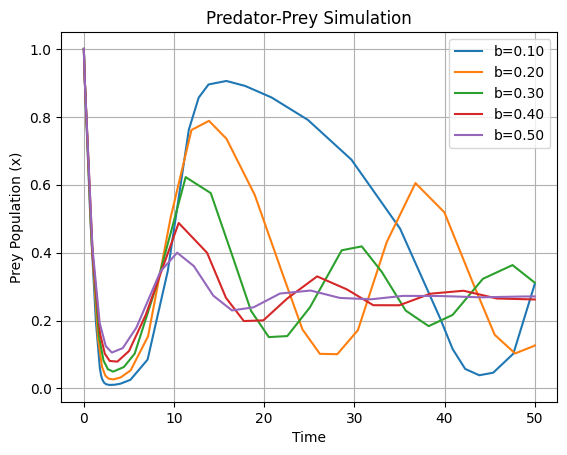

NameError: name 'b_periodic' is not defined

In [9]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt

# Define the predator-prey equations
def predator_prey(t, y, a, b, d):
    x, y = y
    dxdt = x * (1 - x) - (a * x * y) / (d + x)
    dydt = b * y * (1 - y / x)
    return [dxdt, dydt]

# Parameters
a = 1
d = 0.1
b_values = np.linspace(0.1, 0.5, 5)

# Simulation
for b in b_values:
    sol = solve_ivp(predator_prey, [0, 50], [1, 1], args=(a, b, d), dense_output=True)
    plt.plot(sol.t, sol.y[0], label=f'b={b:.2f}')

plt.xlabel('Time')
plt.ylabel('Prey Population (x)')
plt.title('Predator-Prey Simulation')
plt.legend()
plt.grid(True)
plt.show()

# Shooting method
def shooting_method(target, guess, a, b, d):
    def residual(b0):
        sol = solve_ivp(predator_prey, [0, 100], [1, guess], args=(a, b0, d))
        return sol.y[0][-1] - target
    result = root_scalar(residual, bracket=[0.1, 0.5])
    return result.root

# Generalized function to solve ODE and find periodic orbit
def solve_and_find_periodic_orbit(eq_func, initial_conditions, parameters, target_condition, guess, phase_condition=None):
    def phase_residual(guess):
        sol = solve_ivp(eq_func, [0, 100], initial_conditions, args=parameters)
        return sol.y[:, -1] - phase_condition
    b_periodic = shooting_method(target_condition, guess, *parameters[:-1])
    sol_periodic = solve_ivp(eq_func, [0, 100], initial_conditions, args=(*parameters[:-1], b_periodic))
    return sol_periodic, b_periodic


# Phase condition for periodic orbit
phase_condition = [1, 1]  # Initial condition

# Solve for periodic orbit
target_condition = [1, 1]  # Return to initial condition after one period
guess = 0.3  # Initial guess for b
sol_periodic, b_periodic = solve_and_find_periodic_orbit(predator_prey, [1, 1], [a, d, b_periodic], target_condition, guess, phase_condition)

# Plot results
plt.plot(sol_periodic.t, sol_periodic.y[0], label=f'Periodic Orbit (b={b_periodic:.2f})')
plt.xlabel('Time')
plt.ylabel('Prey Population (x)')
plt.title('Predator-Prey System with Periodic Orbit')
plt.legend()
plt.grid(True)
plt.show()
